In [1]:
%load_ext autoreload
%autoreload 2

In [9]:
from pathlib import Path
import torch
import cv2
from matplotlib import pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().parent

# 4. Testing area

In [3]:
from trichomecounter.data.data import get_dataloader
from trichomecounter.utils.utils import get_model_instance_path, load_config, load_model

MODEL_NAME = "model0_density10"#"model0_density10"
CP = "best"
MODELS_DIR = PROJECT_ROOT / "models"

# Load config
model_dir = MODELS_DIR / MODEL_NAME
model_instance_path = get_model_instance_path(model_dir=model_dir, cp=CP)
config_path = model_instance_path / "config.yaml"
cfg = load_config(config_path)

# Create dataloader
test_dataloader = get_dataloader(split="test", cfg=cfg)

# Init model
model = load_model(model_name=MODEL_NAME, 
                    cp=CP) 

# Get device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

c:\Users\adria\OneDrive\Desktop\_\Programming\MachineLearning\TrichomeCounter\TrichomeCounter\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[WARNING] 'best' cp chosen. Should only be used for evaluation or transfer learning. Otherwise number of training epochs is logged incorrectly + optimizer has later state.
[INFO] Loaded model from 'C:\Users\adria\OneDrive\Desktop\_\Programming\MachineLearning\TrichomeCounter\TrichomeCounter\models\model0_density10\best_cp.pth'.


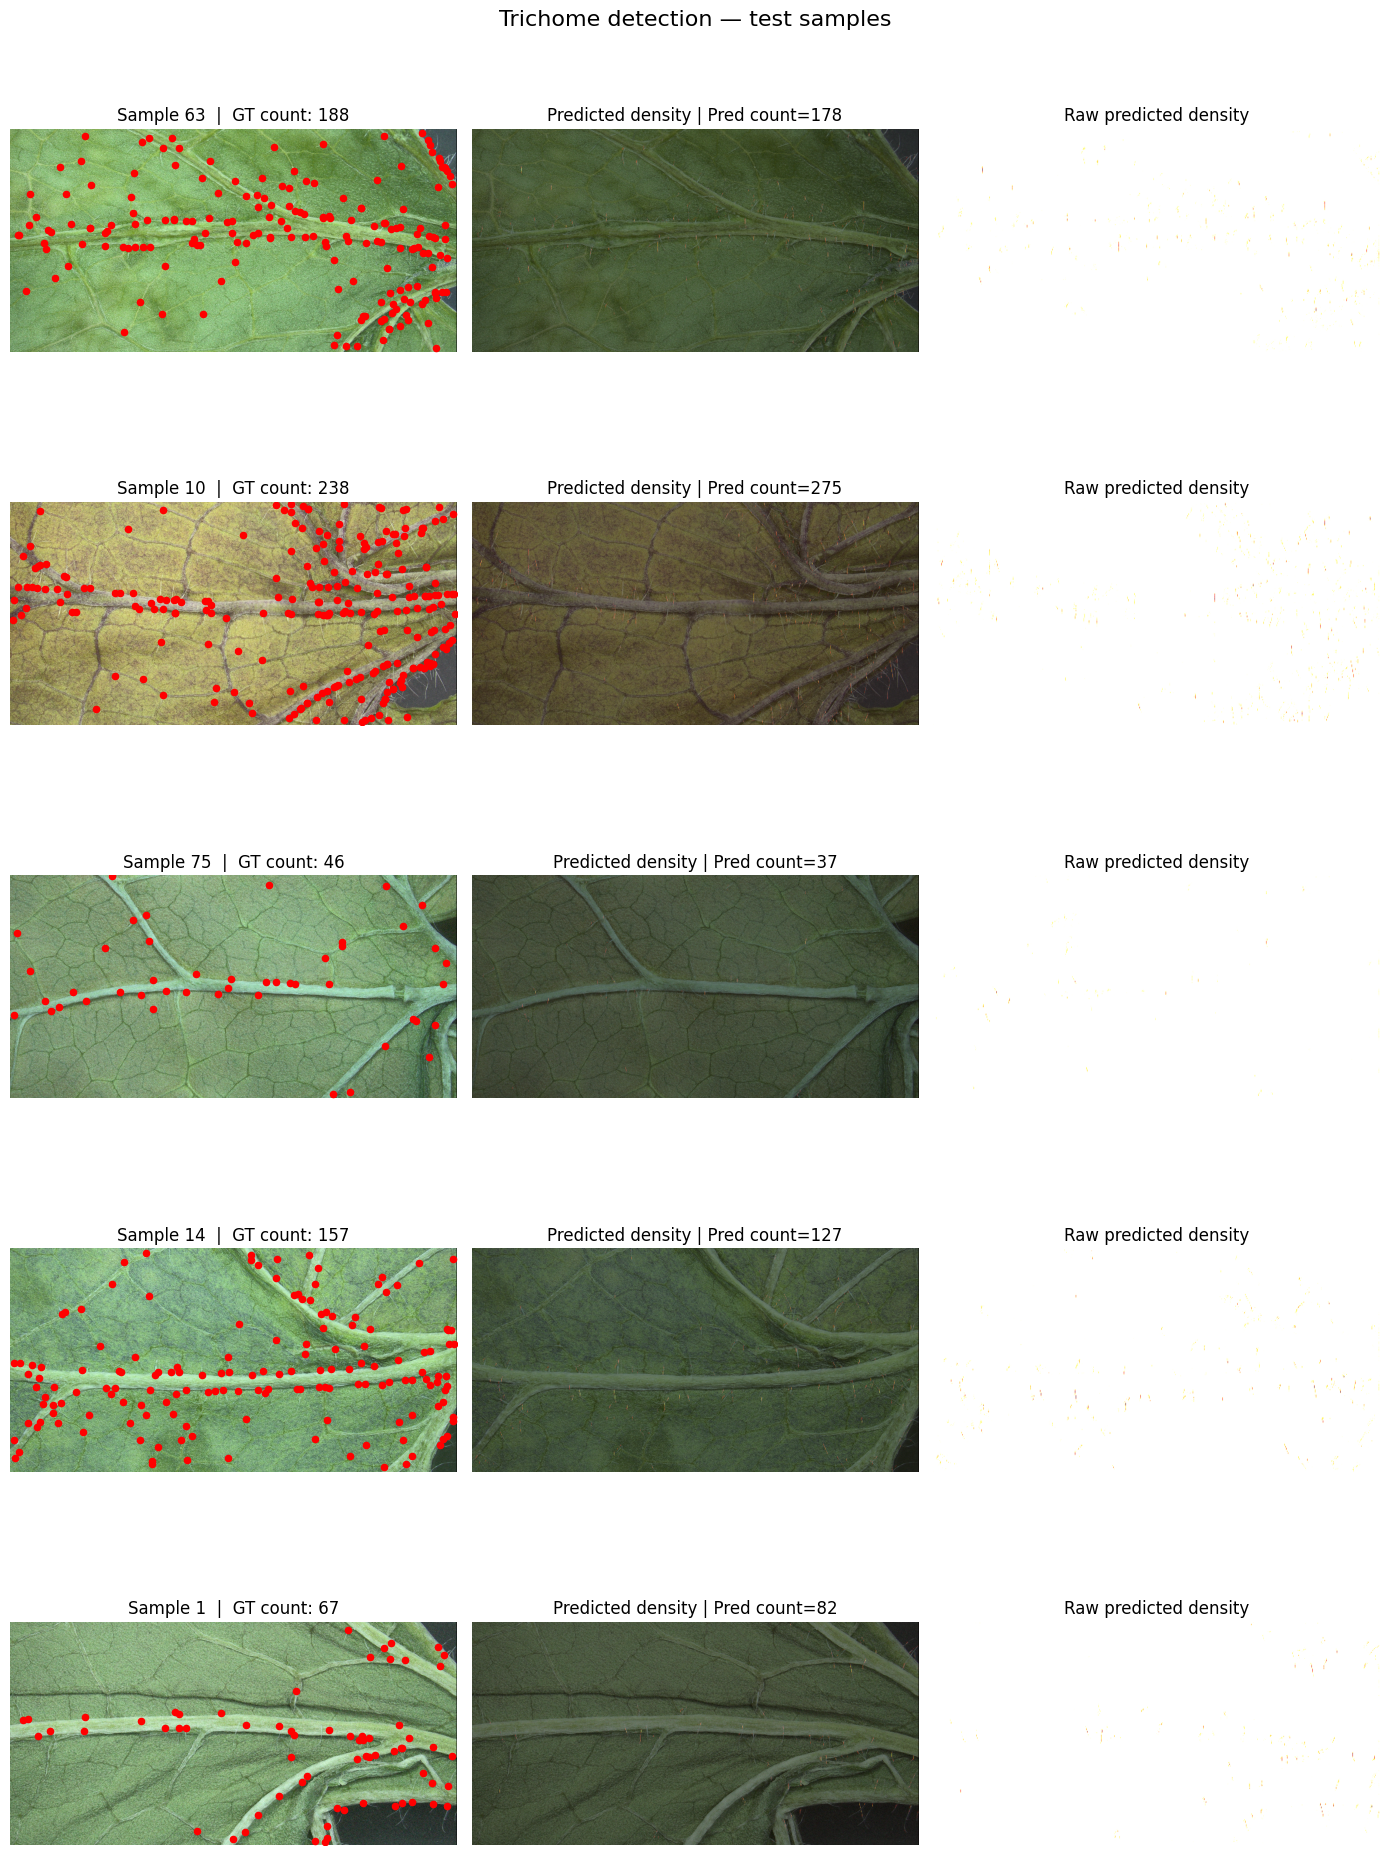

In [4]:
from trichomecounter.utils.visualizations import visualize_test_samples

visualize_test_samples(model, test_dataloader.dataset, device, cfg, CP, n_samples=5, save_fig=False)

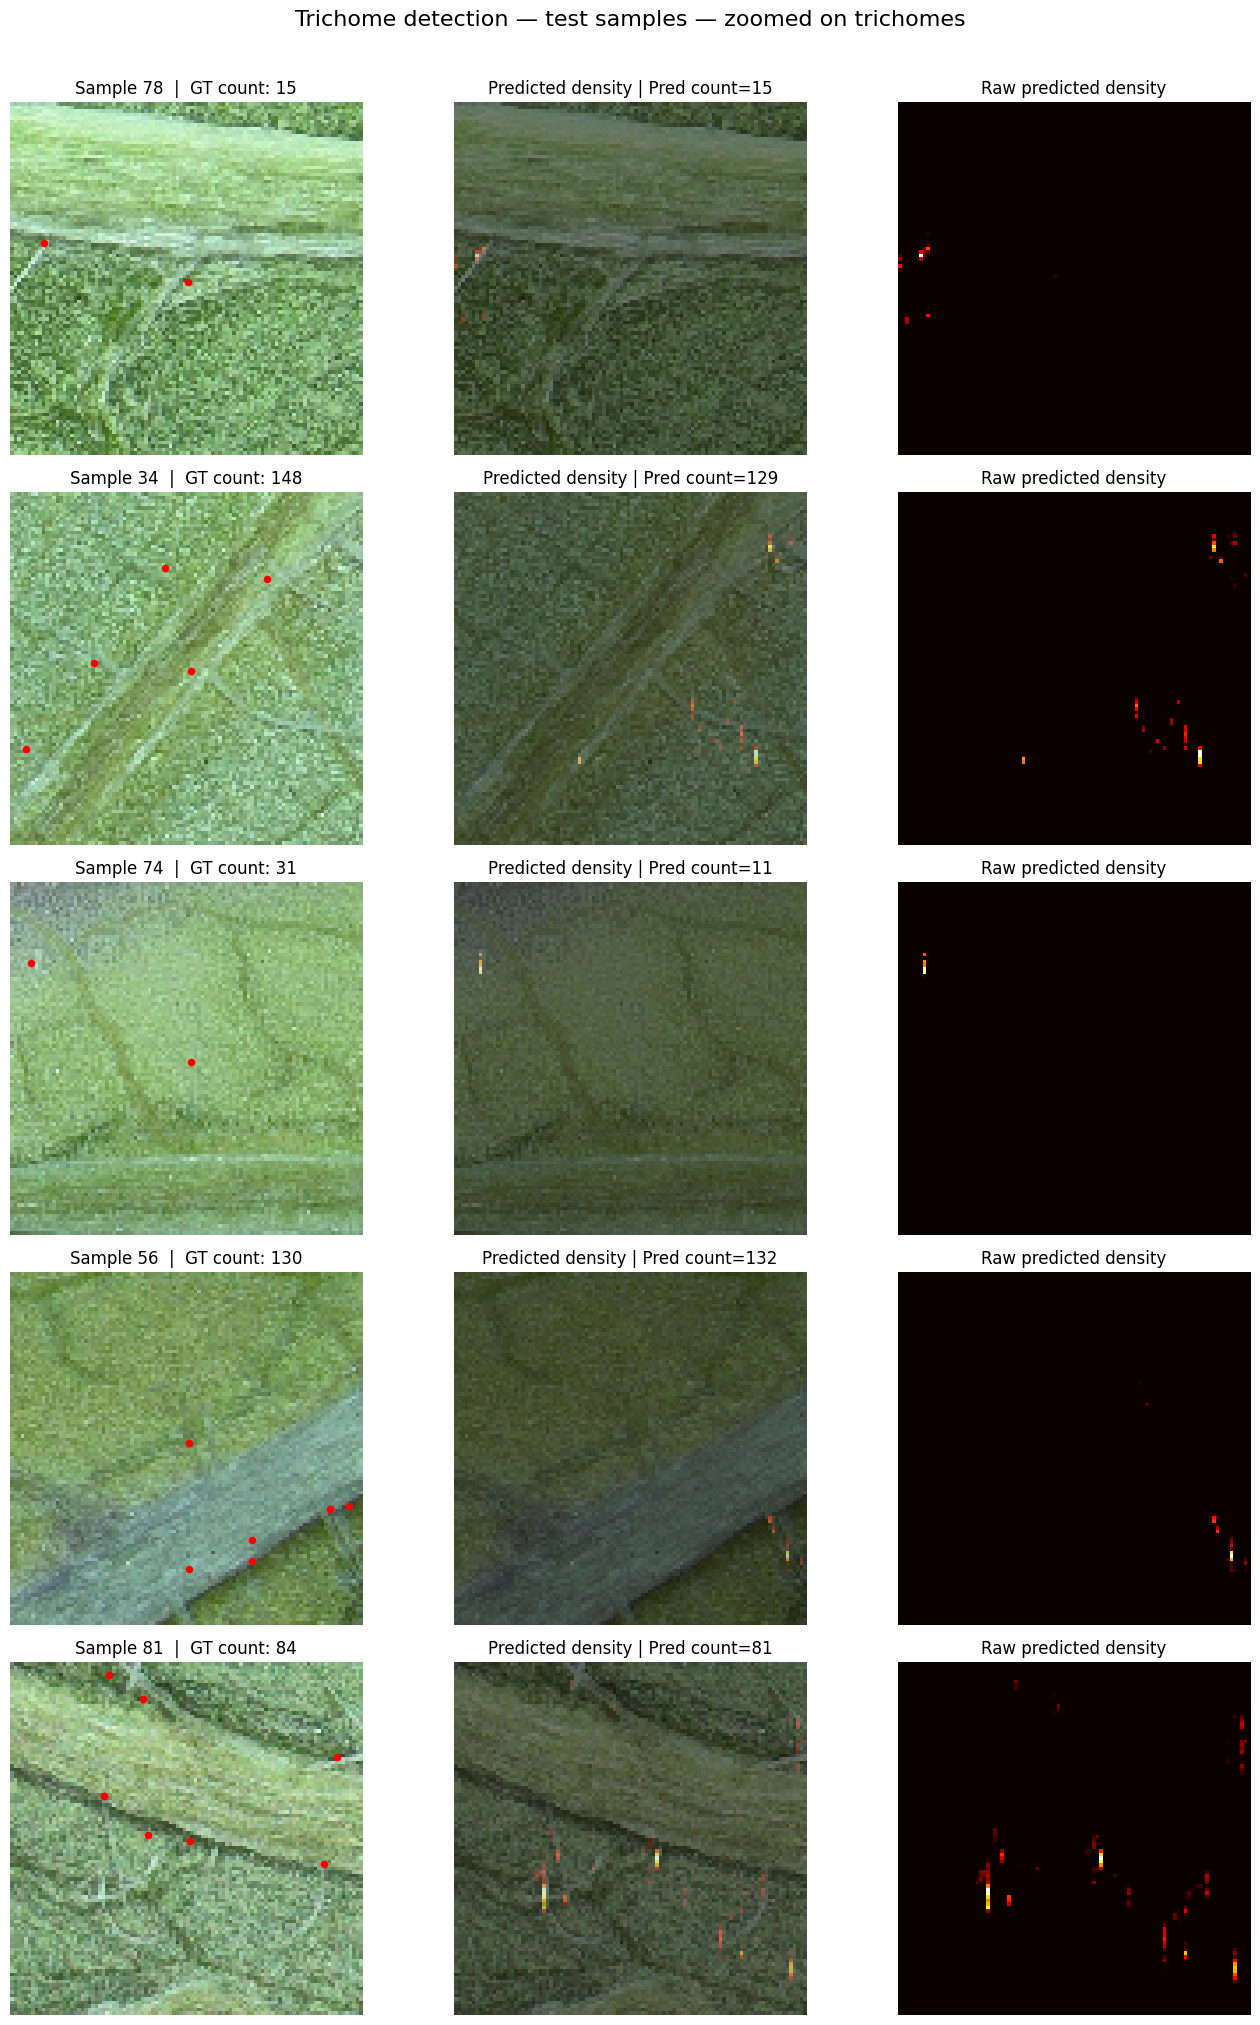

In [5]:
from trichomecounter.utils.visualizations import visualize_test_sample_trichomes

visualize_test_sample_trichomes(model, test_dataloader.dataset, device, cfg, CP, n_samples=5, save_fig=False)

100%|██████████| 6/6 [01:26<00:00, 14.43s/it]


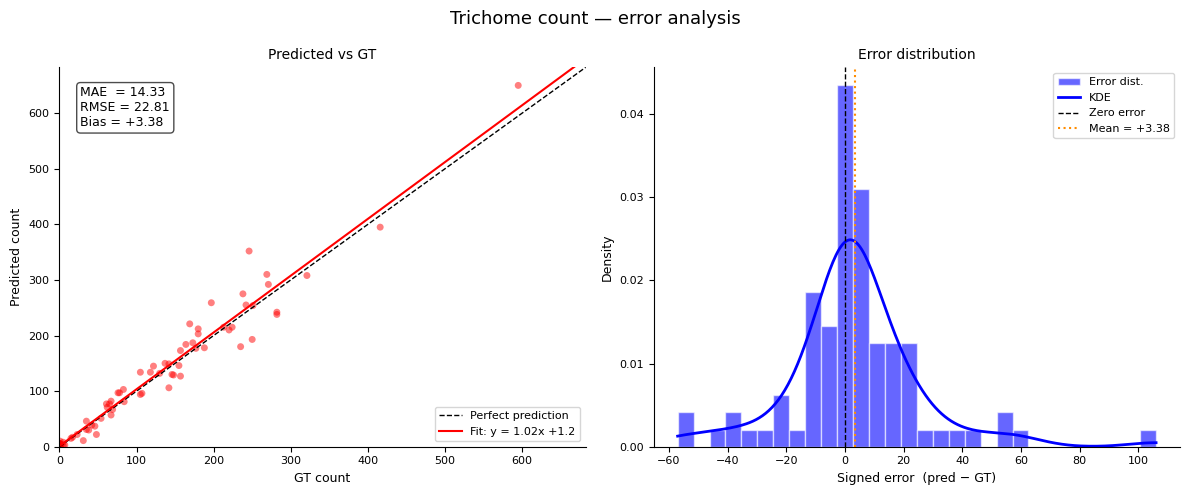

In [6]:
from trichomecounter.model.evaluations import evaluate_on_testset
from trichomecounter.utils.visualizations import plot_error_distribution

results = evaluate_on_testset(model, test_dataloader, device)
plot_error_distribution(results, cfg, CP, save_fig=False)

Model "model0_density10" at a point where predictions partially show capability of trichome detection. Noisy targets likely do not help with improvements anymore.

=> **Idea**: Generate target maps based on a mixture of the model predictions and the original target maps for better training objectives for next gen models: 

`target = alpha * pred + (1 - alpha) * old_target`

In [ ]:
import torch, numpy as np
from pathlib import Path

from trichomecounter.data.data import generate_blend_maps
from trichomecounter.utils.utils import load_model, load_config, get_model_instance_path
from trichomecounter.model.target_maps import generate_density_map


# Hyperprameters
model_root = PROJECT_ROOT / "models"
model_name = "model0_density10"
cp = "best"

# Load model
model = load_model(model_name=model_name, cp=cp)

# Load config
model_dir = Path(model_root) / model_name
model_instance_path = get_model_instance_path(model_dir=model_dir, cp=cp)
config_path = model_instance_path / "config.yaml"
cfg = load_config(config_path)

# Get device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# For each split, generate blend maps
splits = ["train", "val", "test"]
for split in splits:
    generate_blend_maps(split=split, 
                        model=model, 
                        cfg=cfg, 
                        target_map_fun=generate_density_map, 
                        alpha_blend=0.05, 
                        device=device)

[WARNING] 'best' cp chosen. Should only be used for evaluation or transfer learning. Otherwise number of training epochs is logged incorrectly + optimizer has later state.
[INFO] Loaded model from 'models\model0_density10\best_cp.pth'.
[WARNING] Only generate blend maps based on models where no crop is applied, s.t. blend maps can be upsampled to the orignal image scale.
[INFO] Saved 390 blend maps to 'data\preprocessed\train\blend_maps'
[WARNING] Only generate blend maps based on models where no crop is applied, s.t. blend maps can be upsampled to the orignal image scale.
[INFO] Saved 82 blend maps to 'data\preprocessed\val\blend_maps'
[WARNING] Only generate blend maps based on models where no crop is applied, s.t. blend maps can be upsampled to the orignal image scale.
[INFO] Saved 89 blend maps to 'data\preprocessed\test\blend_maps'


N_Trichomes: 86 | Density: 86.0


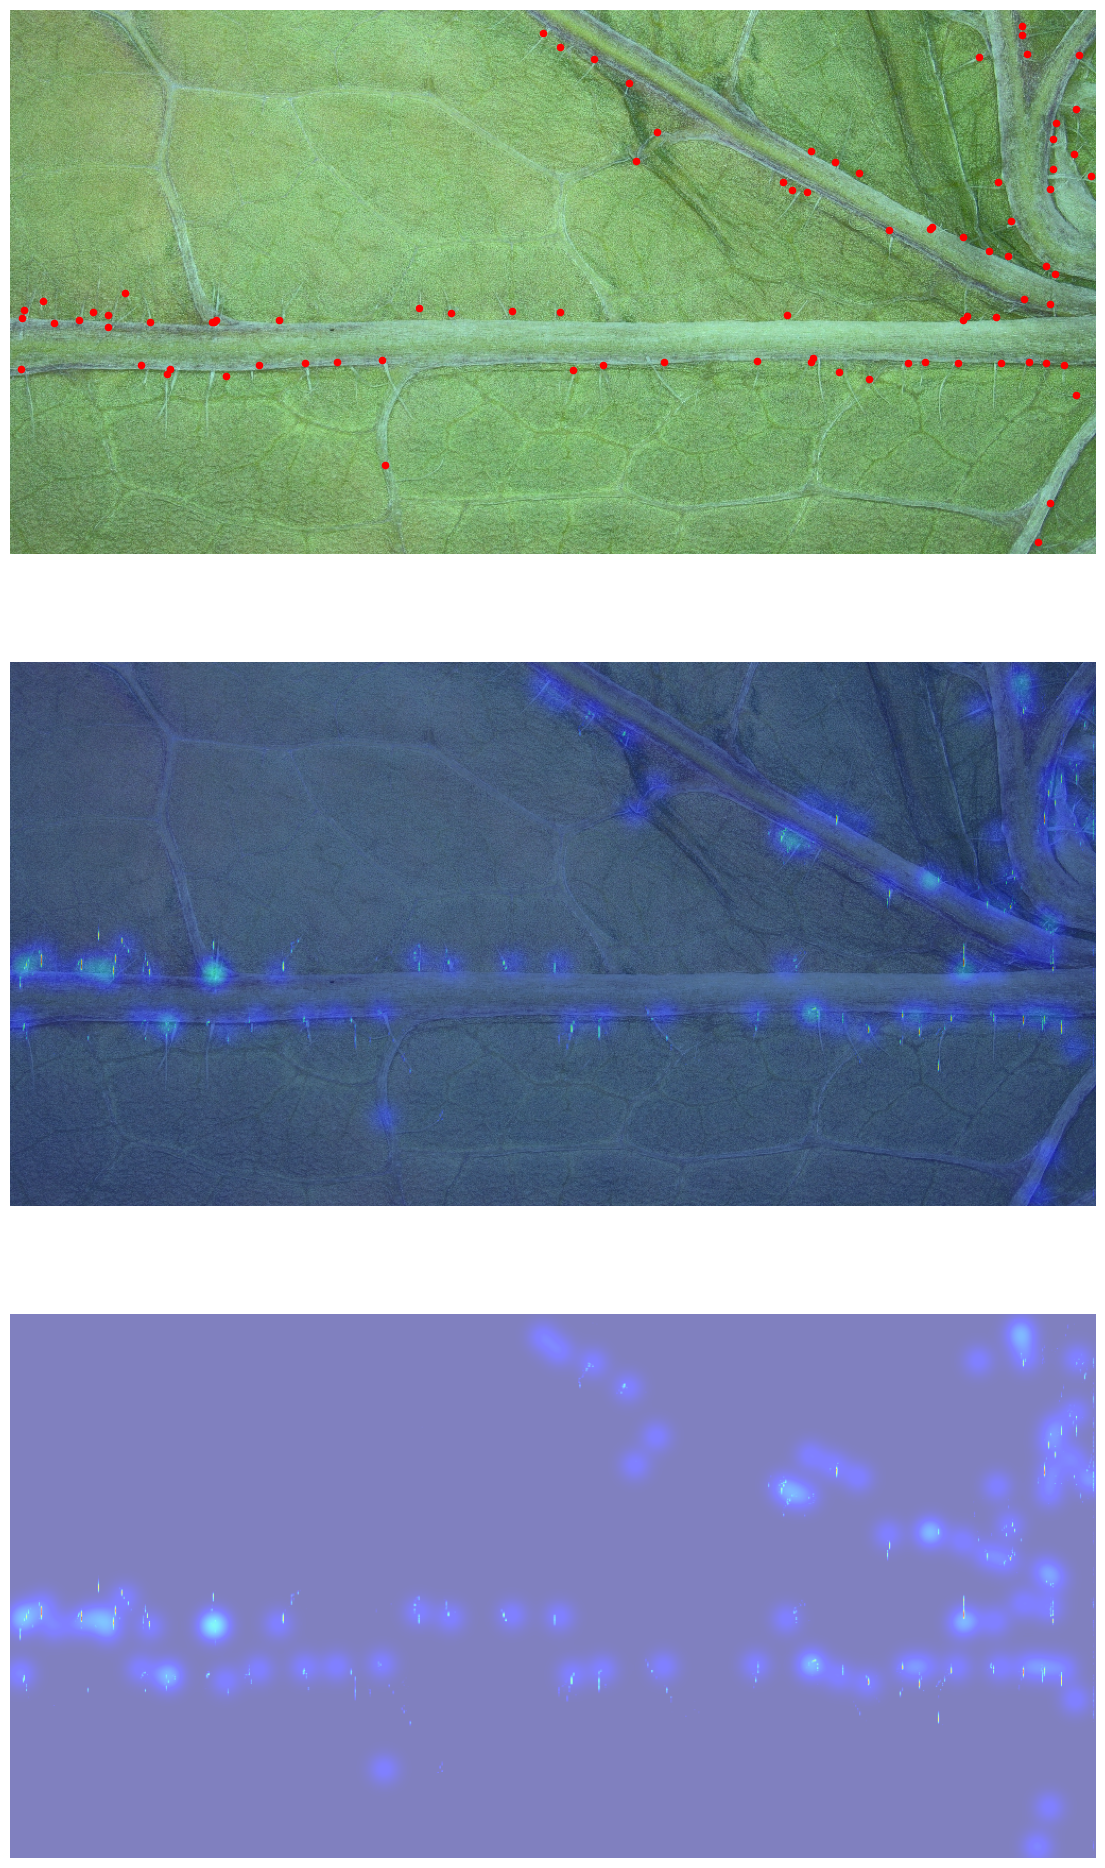

In [10]:
# Sanity check: Inspect blend_maps
from trichomecounter.utils.utils import get_random_data_paths
from trichomecounter.utils.visualizations import plot_image, plot_density_map
from trichomecounter.data.data_transformations import ResizeShortSide

_, _, img_path, coord_path = get_random_data_paths()
data_id = img_path.stem
blend_path = Path(img_path.parent.parent) / "blend_maps" / f"{data_id}.npz"

img = cv2.imread(str(img_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
coords = np.load(coord_path)
img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
coords = torch.from_numpy(coords).float()
target_map = torch.from_numpy(np.load(blend_path)["map"]).unsqueeze(0)

resize = ResizeShortSide(512)
img, coords, target_map = resize(img, coords, target_map)
print(f"N_Trichomes: {len(coords)} | Density: {target_map.sum()}")

fig, ax = plt.subplots(3,1,figsize=(16,24))

plot_image(img=img,
           coords=coords,
           ax=ax[0])
plot_density_map(density=target_map.squeeze(),
                 img=img,
                 ax=ax[1])
plot_density_map(density=target_map.squeeze(),
                 ax=ax[2]);